<a href="https://colab.research.google.com/github/amit-sahu-a11y/3d_video_classification/blob/main/muti_model_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Multi-Modal Classification with Dummy Data

This example demonstrates a basic multi-modal classification setup using Keras/TensorFlow. We'll create dummy text and image features, combine them, and train a simple neural network for classification.

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define parameters for the dummy dataset
num_samples = 1000
text_feature_dim = 50  # e.g., output from a text embedding model
image_feature_dim = 100 # e.g., output from a pre-trained CNN
num_classes = 2      # Binary classification

# Generate dummy text features
# These could be embeddings from a pre-trained language model
np.random.seed(42)
text_features = np.random.rand(num_samples, text_feature_dim).astype(np.float32)

# Generate dummy image features
# These could be features extracted from a pre-trained vision model
image_features = np.random.rand(num_samples, image_feature_dim).astype(np.float32)

# Generate dummy labels for classification
# Create a simple rule for labels based on some features for illustrative purposes
# For instance, if sum of first few text features and image features is high, it's class 1
labels = (np.sum(text_features[:, :5], axis=1) + np.sum(image_features[:, :10], axis=1) > 5).astype(int)

# Normalize features (optional but good practice)
scaler_text = StandardScaler()
text_features_scaled = scaler_text.fit_transform(text_features)

scaler_image = StandardScaler()
image_features_scaled = scaler_image.fit_transform(image_features)

print(f"Text features shape: {text_features_scaled.shape}")
print(f"Image features shape: {image_features_scaled.shape}")
print(f"Labels shape: {labels.shape}")

# Split data into training and testing sets
X_text_train, X_text_test, X_image_train, X_image_test, y_train, y_test = train_test_split(
    text_features_scaled, image_features_scaled, labels, test_size=0.2, random_state=42
)

print("\nData split into training and testing sets:")
print(f"X_text_train shape: {X_text_train.shape}")
print(f"X_image_train shape: {X_image_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_text_test shape: {X_text_test.shape}")
print(f"X_image_test shape: {X_image_test.shape}")
print(f"y_test shape: {y_test.shape}")

Text features shape: (1000, 50)
Image features shape: (1000, 100)
Labels shape: (1000,)

Data split into training and testing sets:
X_text_train shape: (800, 50)
X_image_train shape: (800, 100)
y_train shape: (800,)
X_text_test shape: (200, 50)
X_image_test shape: (200, 100)
y_test shape: (200,)


### Build the Multi-Modal Model

Now, let's define the neural network architecture. We'll have two separate input branches for text and image features, process them independently, and then concatenate their outputs before a final classification layer.

In [2]:
# Define input layers for each modality
text_input = keras.Input(shape=(text_feature_dim,), name="text_input")
image_input = keras.Input(shape=(image_feature_dim,), name="image_input")

# Branch for text features
x_text = layers.Dense(64, activation="relu")(text_input)
x_text = layers.Dropout(0.3)(x_text)
x_text = layers.Dense(32, activation="relu")(x_text)

# Branch for image features
x_image = layers.Dense(128, activation="relu")(image_input)
x_image = layers.Dropout(0.3)(x_image)
x_image = layers.Dense(64, activation="relu")(x_image)

# Concatenate the outputs of the two branches
concatenated = layers.concatenate([x_text, x_image])

# Classification head
z = layers.Dense(64, activation="relu")(concatenated)
z = layers.Dropout(0.4)(z)
output = layers.Dense(num_classes, activation="softmax", name="output")(z) # Softmax for multi-class, sigmoid for binary

# Create the multi-modal model
model = keras.Model(inputs=[text_input, image_input], outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      3,264 │ text_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     12,928 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │        130 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,866 (128.38 KB)

 Trainable params: 32,866 (128.38 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the Model

With the model defined, we can now compile it with an optimizer, loss function, and metrics, and then train it using our dummy data.

In [3]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy", # Use sparse_categorical_crossentropy for integer labels
    metrics=["accuracy"],
)

# Train the model
history = model.fit(
    {"text_input": X_text_train, "image_input": X_image_train},
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9328 - loss: 0.2096 - val_accuracy: 0.9937 - val_loss: 0.0411
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9875 - loss: 0.0815 - val_accuracy: 0.9937 - val_loss: 0.0417
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0613 - val_accuracy: 0.9937 - val_loss: 0.0402
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0502 - val_accuracy: 0.9937 - val_loss: 0.0404
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9875 - loss: 0.0402 - val_accuracy: 0.9937 - val_loss: 0.0403
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9875 - loss: 0.0322 - val_accuracy: 0.9937 - val_loss: 0.0401
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0291 - val_accuracy: 0.9937 - val_loss: 0.0406
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0255 - val_accuracy: 0.9937 - val_loss

### Evaluate the Model

Finally, let's evaluate the trained model on the test set to see its performance.

In [4]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(
    {"text_input": X_text_test, "image_input": X_image_test},
    y_test,
    verbose=0
)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
predictions = model.predict({"text_input": X_text_test, "image_input": X_image_test})
predicted_classes = np.argmax(predictions, axis=1)

print("\nExample predictions (first 10):")
for i in range(10):
    print(f"True: {y_test[i]}, Predicted: {predicted_classes[i]}, Probabilities: {predictions[i]}")


Test Loss: 0.1354
Test Accuracy: 0.9750
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Example predictions (first 10):
True: 1, Predicted: 1, Probabilities: [0.00184475 0.99815524]
True: 1, Predicted: 1, Probabilities: [0.00486119 0.9951387 ]
True: 1, Predicted: 1, Probabilities: [2.1891523e-04 9.9978113e-01]
True: 1, Predicted: 1, Probabilities: [2.3796722e-04 9.9976206e-01]
True: 1, Predicted: 1, Probabilities: [2.2126592e-04 9.9977875e-01]
True: 1, Predicted: 1, Probabilities: [1.9004894e-04 9.9980998e-01]
True: 1, Predicted: 1, Probabilities: [5.290681e-04 9.994710e-01]
True: 1, Predicted: 1, Probabilities: [7.8130033e-05 9.9992186e-01]
True: 1, Predicted: 1, Probabilities: [3.5783896e-04 9.9964213e-01]
True: 1, Predicted: 1, Probabilities: [0.00257782 0.99742216]


### Plot Training and Validation Accuracy

Let's visualize the training and validation accuracy over epochs to understand the model's learning process and identify potential overfitting.

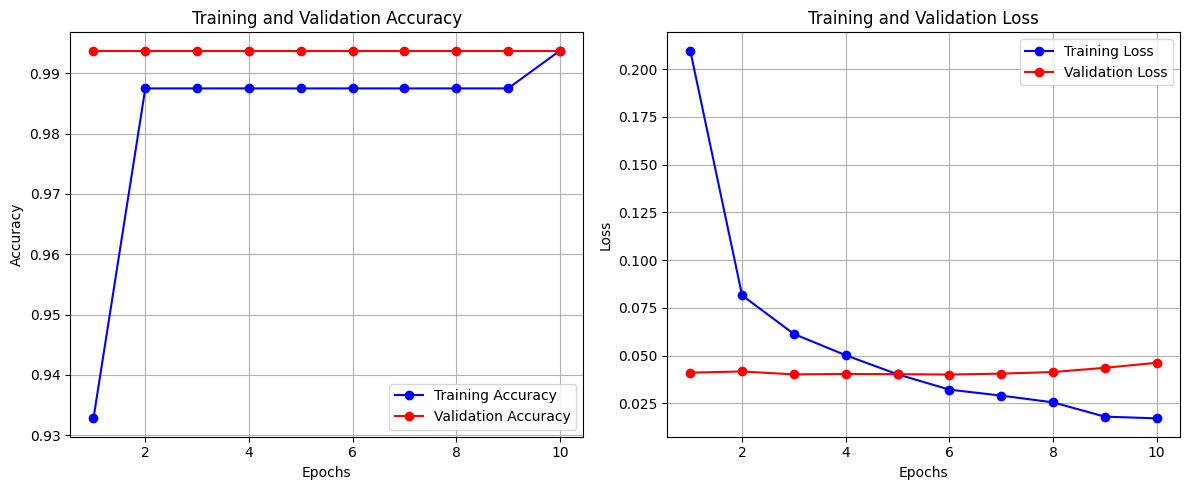

In [5]:
import matplotlib.pyplot as plt

# Get accuracy and loss values from history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Confusion Matrix

To get a detailed view of the classification performance, let's generate a confusion matrix. This will show us how many samples were correctly and incorrectly classified for each class.

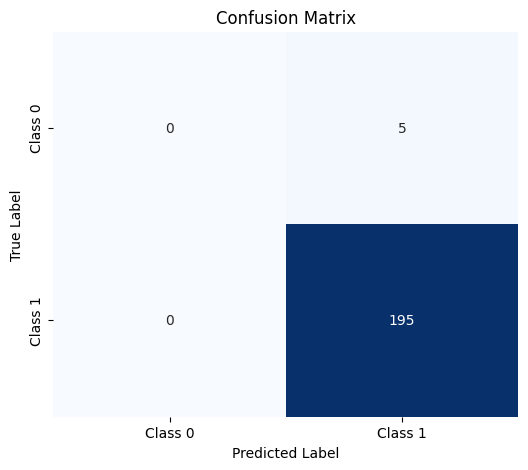

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Class {i}' for i in range(num_classes)],
            yticklabels=[f'Class {i}' for i in range(num_classes)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

Beyond the confusion matrix, the classification report provides precision, recall, and F1-score for each class, offering a more detailed understanding of the model's performance.

In [7]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, predicted_classes, target_names=[f'Class {i}' for i in range(num_classes)])

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         5
     Class 1       0.97      1.00      0.99       195

    accuracy                           0.97       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.95      0.97      0.96       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Addressing Class Imbalance with Class Weights

As observed from the confusion matrix and classification report, the model struggles with the minority class (Class 0). To mitigate this, we can introduce `class_weight` during model training. This will assign a higher penalty to errors made on the minority class, encouraging the model to learn its patterns better.

In [8]:
from sklearn.utils import class_weight

# Calculate class weights for the training data
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format required by Keras
class_weight_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weight_dict)

# Re-create and re-compile the model (or just compile if the architecture is the same)
# It's good practice to re-initialize weights if retraining from scratch with new strategy

# Define input layers for each modality (re-using previous definitions for simplicity)
text_input_cw = keras.Input(shape=(text_feature_dim,), name="text_input_cw")
image_input_cw = keras.Input(shape=(image_feature_dim,), name="image_input_cw")

# Branch for text features
x_text_cw = layers.Dense(64, activation="relu")(text_input_cw)
x_text_cw = layers.Dropout(0.3)(x_text_cw)
x_text_cw = layers.Dense(32, activation="relu")(x_text_cw)

# Branch for image features
x_image_cw = layers.Dense(128, activation="relu")(image_input_cw)
x_image_cw = layers.Dropout(0.3)(x_image_cw)
x_image_cw = layers.Dense(64, activation="relu")(x_image_cw)

# Concatenate the outputs of the two branches
concatenated_cw = layers.concatenate([x_text_cw, x_image_cw])

# Classification head
z_cw = layers.Dense(64, activation="relu")(concatenated_cw)
z_cw = layers.Dropout(0.4)(z_cw)
output_cw = layers.Dense(num_classes, activation="softmax", name="output_cw")(z_cw)

model_cw = keras.Model(inputs=[text_input_cw, image_input_cw], outputs=output_cw)

model_cw.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("\nRetraining model with class weights...")
history_cw = model_cw.fit(
    {"text_input_cw": X_text_train, "image_input_cw": X_image_train},
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict, # Apply class weights here
    verbose=1
)

print("\nRetraining with class weights complete!")

Calculated Class Weights: {0: np.float64(44.44444444444444), 1: np.float64(0.5056890012642224)}

Retraining model with class weights...
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9594 - loss: 2.0914 - val_accuracy: 0.9937 - val_loss: 0.0836
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9812 - loss: 1.2745 - val_accuracy: 0.9875 - val_loss: 0.2331
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8813 - loss: 0.5971 - val_accuracy: 0.9563 - val_loss: 0.3748
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8891 - loss: 0.3958 - val_accuracy: 0.9750 - val_loss: 0.2378
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9438 - loss: 0.2816 - val_accuracy: 0.9750 - val_loss: 0.1754
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9547 - loss: 0.2547 - val_accuracy: 0.9812 - val_loss: 0.1182
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9719 - loss: 0.1198 - val_accuracy: 0.9812

### Evaluate Model with Class Weights

Let's re-evaluate the model's performance after training with class weights, paying close attention to the metrics for Class 0.


Test Loss (with class weights): 0.1064
Test Accuracy (with class weights): 0.9700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


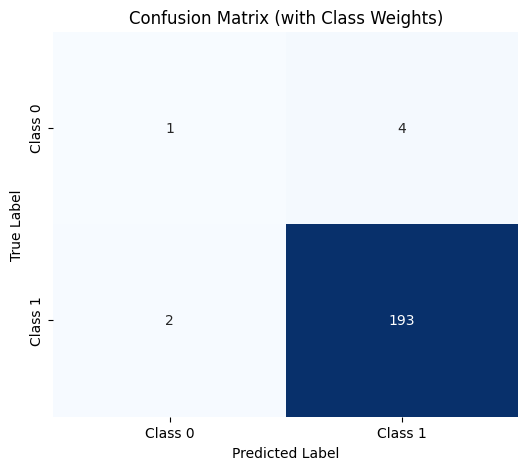


Classification Report (with Class Weights):
              precision    recall  f1-score   support

     Class 0       0.33      0.20      0.25         5
     Class 1       0.98      0.99      0.98       195

    accuracy                           0.97       200
   macro avg       0.66      0.59      0.62       200
weighted avg       0.96      0.97      0.97       200



In [9]:
# Evaluate the re-trained model on the test set
loss_cw, accuracy_cw = model_cw.evaluate(
    {"text_input_cw": X_text_test, "image_input_cw": X_image_test},
    y_test,
    verbose=0
)

print(f"\nTest Loss (with class weights): {loss_cw:.4f}")
print(f"Test Accuracy (with class weights): {accuracy_cw:.4f}")

# Make predictions with the re-trained model
predictions_cw = model_cw.predict({"text_input_cw": X_text_test, "image_input_cw": X_image_test})
predicted_classes_cw = np.argmax(predictions_cw, axis=1)

# Generate new confusion matrix
cm_cw = confusion_matrix(y_test, predicted_classes_cw)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cw, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Class {i}' for i in range(num_classes)],
            yticklabels=[f'Class {i}' for i in range(num_classes)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (with Class Weights)')
plt.show()

# Generate new classification report
report_cw = classification_report(y_test, predicted_classes_cw, target_names=[f'Class {i}' for i in range(num_classes)])
print("\nClassification Report (with Class Weights):")
print(report_cw)

### Compare Model Performance: Without vs. With Class Weights

To effectively assess the impact of class weights, let's compare the classification reports side-by-side. We will focus on precision, recall, and F1-score for each class, as well as the overall macro and weighted averages.

In [11]:
import pandas as pd
import re

def parse_classification_report(report_str, model_name):
    lines = report_str.split('\n')
    data = []
    # Updated regex to correctly capture 'Class 0' or 'Class 1'
    metrics_pattern = re.compile(r'\s*(Class \d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)')

    for line in lines:
        match = metrics_pattern.match(line)
        if match:
            class_name, precision, recall, f1_score, support = match.groups()
            data.append({
                'Metric': class_name.strip(),
                f'{model_name} Precision': float(precision),
                f'{model_name} Recall': float(recall),
                f'{model_name} F1-Score': float(f1_score),
                f'{model_name} Support': int(support)
            })

    # Extract accuracy, macro avg, and weighted avg
    accuracy_line = [l for l in lines if 'accuracy' in l.lower()][0]
    accuracy_value = float(re.search(r'accuracy\s+(\d+\.\d+)', accuracy_line).group(1))

    macro_avg_line = [l for l in lines if 'macro avg' in l.lower()][0]
    macro_avg_values = re.findall(r'\d+\.\d+', macro_avg_line)
    macro_avg_precision, macro_avg_recall, macro_avg_f1 = map(float, macro_avg_values[:3])

    weighted_avg_line = [l for l in lines if 'weighted avg' in l.lower()][0]
    weighted_avg_values = re.findall(r'\d+\.\d+', weighted_avg_line)
    weighted_avg_precision, weighted_avg_recall, weighted_avg_f1 = map(float, weighted_avg_values[:3])

    parsed_data = {
        'Class 0': {'Precision': data[0][f'{model_name} Precision'], 'Recall': data[0][f'{model_name} Recall'], 'F1-Score': data[0][f'{model_name} F1-Score'], 'Support': data[0][f'{model_name} Support']},
        'Class 1': {'Precision': data[1][f'{model_name} Precision'], 'Recall': data[1][f'{model_name} Recall'], 'F1-Score': data[1][f'{model_name} F1-Score'], 'Support': data[1][f'{model_name} Support']},
        'accuracy': accuracy_value,
        'macro avg': {'Precision': macro_avg_precision, 'Recall': macro_avg_recall, 'F1-Score': macro_avg_f1},
        'weighted avg': {'Precision': weighted_avg_precision, 'Recall': weighted_avg_recall, 'F1-Score': weighted_avg_f1},
    }
    return parsed_data

# Parse the reports
report_no_cw_parsed = parse_classification_report(report, 'Without CW')
report_with_cw_parsed = parse_classification_report(report_cw, 'With CW')

# Prepare data for DataFrame
data_for_df = []

# Class 0 and Class 1 metrics
for class_name in ['Class 0', 'Class 1']:
    data_for_df.append({
        'Metric': class_name,
        'Precision (Without CW)': report_no_cw_parsed[class_name]['Precision'],
        'Recall (Without CW)': report_no_cw_parsed[class_name]['Recall'],
        'F1-Score (Without CW)': report_no_cw_parsed[class_name]['F1-Score'],
        'Support (Without CW)': report_no_cw_parsed[class_name]['Support'],
        'Precision (With CW)': report_with_cw_parsed[class_name]['Precision'],
        'Recall (With CW)': report_with_cw_parsed[class_name]['Recall'],
        'F1-Score (With CW)': report_with_cw_parsed[class_name]['F1-Score'],
        'Support (With CW)': report_with_cw_parsed[class_name]['Support']
    })

# Overall Accuracy
data_for_df.append({
    'Metric': 'Overall Accuracy',
    'Precision (Without CW)': report_no_cw_parsed['accuracy'],
    'Recall (Without CW)': report_no_cw_parsed['accuracy'],
    'F1-Score (Without CW)': report_no_cw_parsed['accuracy'],
    'Support (Without CW)': '', # Not applicable for overall accuracy
    'Precision (With CW)': report_with_cw_parsed['accuracy'],
    'Recall (With CW)': report_with_cw_parsed['accuracy'],
    'F1-Score (With CW)': report_with_cw_parsed['accuracy'],
    'Support (With CW)': ''  # Not applicable for overall accuracy
})

# Macro Average metrics
data_for_df.append({
    'Metric': 'Macro Avg',
    'Precision (Without CW)': report_no_cw_parsed['macro avg']['Precision'],
    'Recall (Without CW)': report_no_cw_parsed['macro avg']['Recall'],
    'F1-Score (Without CW)': report_no_cw_parsed['macro avg']['F1-Score'],
    'Support (Without CW)': '',
    'Precision (With CW)': report_with_cw_parsed['macro avg']['Precision'],
    'Recall (With CW)': report_with_cw_parsed['macro avg']['Recall'],
    'F1-Score (With CW)': report_with_cw_parsed['macro avg']['F1-Score'],
    'Support (With CW)': ''
})

# Weighted Average metrics
data_for_df.append({
    'Metric': 'Weighted Avg',
    'Precision (Without CW)': report_no_cw_parsed['weighted avg']['Precision'],
    'Recall (Without CW)': report_no_cw_parsed['weighted avg']['Recall'],
    'F1-Score (Without CW)': report_no_cw_parsed['weighted avg']['F1-Score'],
    'Support (Without CW)': '',
    'Precision (With CW)': report_with_cw_parsed['weighted avg']['Precision'],
    'Recall (With CW)': report_with_cw_parsed['weighted avg']['Recall'],
    'F1-Score (With CW)': report_with_cw_parsed['weighted avg']['F1-Score'],
    'Support (With CW)': ''
})

comparison_df = pd.DataFrame(data_for_df)
comparison_df.set_index('Metric', inplace=True)

display(comparison_df.style.set_caption("Model Performance Comparison (Without vs. With Class Weights)"))

,Precision (Without CW),Recall (Without CW),F1-Score (Without CW),Support (Without CW),Precision (With CW),Recall (With CW),F1-Score (With CW),Support (With CW)
Metric,,,,,,,,
Class 0,0.000000,0.000000,0.000000,5,0.330000,0.200000,0.250000,5
Class 1,0.970000,1.000000,0.990000,195,0.980000,0.990000,0.980000,195
Overall Accuracy,0.970000,0.970000,0.970000,,0.970000,0.970000,0.970000,
Macro Avg,0.490000,0.500000,0.490000,,0.660000,0.590000,0.620000,
Weighted Avg,0.950000,0.970000,0.960000,,0.960000,0.970000,0.970000,
